# Finding Stars in Someone Else's Astronomy Homework - Stacked Image Edition

## Brief Background
This notebook mimics the process of `fits_measure.ipynb` but operates on the **`best_stacked_image.fits`** generated by the calibration and stacking demonstration pipeline. We perform hot and cold pixel repair, 1-D and 2-D Difference-of-Gaussians (DoG) bandpass filtering to locate stars, and sub-pixel centroiding to estimate integrated counts.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import sys
from scipy import ndimage
from astropy.io import fits
from astropy import wcs
import pandas as pd
from astropy import units as u
from astropy.coordinates import SkyCoord

import os
project_root = os.path.abspath(os.path.join(sys.path[0], '..', '..'))
for path in [sys.path[0] if sys.path else '', os.getcwd()]:
    if not path: continue
    p = os.path.abspath(path)
    while p:
        if os.path.isdir(os.path.join(p, 'package')) and os.path.isfile(os.path.join(p, 'pytest.ini')):
            project_root = p
            break
        parent = os.path.dirname(p)
        if parent == p: break
        p = parent
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from package.src.astropipeline import astropipeline_etl as aple
from package.src.astropipeline import astropipeline_measure as aplm

In [2]:
instcal_sample = fits.open('best_stacked_image.fits')
hdr = instcal_sample[0].header
img2 = instcal_sample[0].data 
img2 = np.nan_to_num(img2, nan=0.0)
img2[img2 < 0] = 0 # remove pixels that came back negative
instcal_sample.close()

print('Citations for the stacked FITS image:\n')
print('--Stacking Method: ' + str(hdr.get('STACKMETHOD')))
print('--Background Subtraction: ' + str(hdr.get('BGSUB')))
print('--Sigma Clipping: ' + str(hdr.get('SIGMACLIP')))
print('--Average SNR: ' + str(hdr.get('AVG_SNR')))

Citations for the stacked FITS image:

--Stacking Method: median
--Background Subtraction: Wavelet Decomposition
--Sigma Clipping: True
--Average SNR: 7.08206873825853


In [3]:
def myHist100(data):
    """
    Convenience function, calculates and plots 100-bin histogram
    """
    clean_data = data[np.isfinite(data)]
    hist_counts, bin_edges = np.histogram(clean_data, bins=100)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.bar(bin_centers, hist_counts, width=(bin_edges[1] - bin_edges[0]))
    return hist_counts, bin_centers

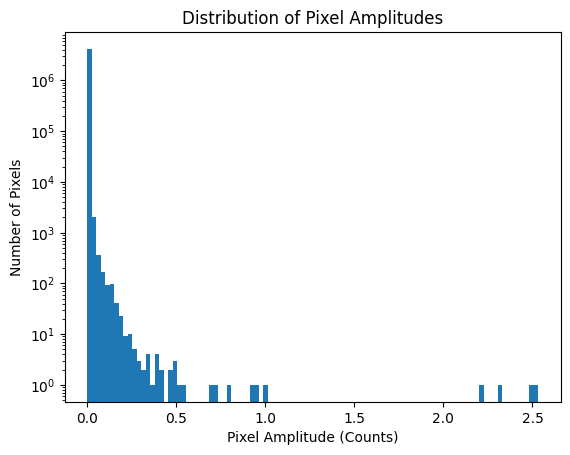

In [4]:
myHist100(img2)
plt.yscale('log')
plt.title('Distribution of Pixel Amplitudes')
bunit = hdr.get('BUNIT', 'Counts')
plt.xlabel(f'Pixel Amplitude ({bunit})')
plt.ylabel('Number of Pixels')
plt.show()

Checking 19092 potential hot pixel outliers...
Repaired hot pixel at location: 4.00, 1468.00 (value: 2.53 -> 0.01)
Repaired hot pixel at location: 0.00, 1696.00 (value: 2.50 -> 0.40)
Repaired hot pixel at location: 9.00, 1344.00 (value: 2.32 -> 0.05)
Repaired hot pixel at location: 4.00, 1373.00 (value: 2.21 -> 0.00)
Repaired hot pixel at location: 0.00, 1430.00 (value: 0.99 -> 0.01)
Repaired hot pixel at location: 1.00, 725.00 (value: 0.96 -> 0.01)


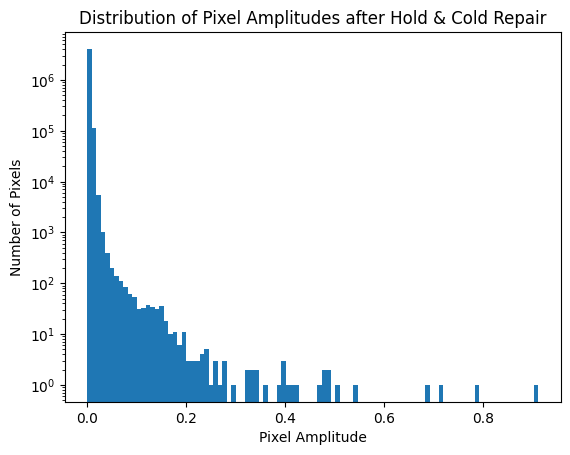

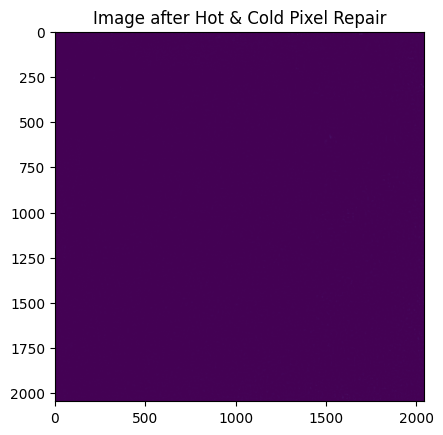

In [5]:
clean_img2 = aplm.repair_hot_pixels(img2)
clean_img2 = aplm.repair_cold_pixels(clean_img2, min_threshold=3)

plt.figure()
myHist100(clean_img2)
plt.yscale('log')
plt.title('Distribution of Pixel Amplitudes after Hold & Cold Repair')
plt.xlabel('Pixel Amplitude')
plt.ylabel('Number of Pixels')

plt.figure()
plt.imshow(np.log1p(clean_img2))
plt.title('Image after Hot & Cold Pixel Repair')
plt.show()

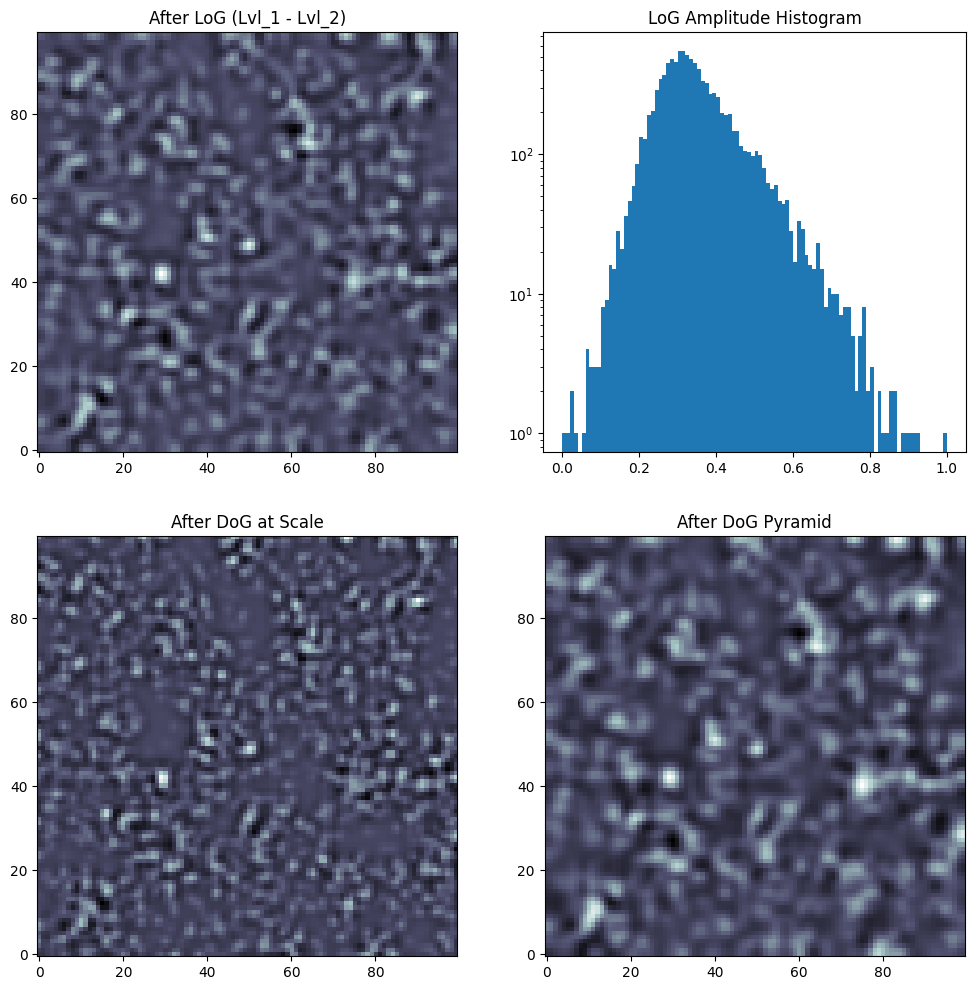

In [6]:
from skimage.transform import pyramid_gaussian, pyramid_expand, pyramid_laplacian
from skimage.filters import difference_of_gaussians

# Crop a section around a visible star in the stacked image
img2_crop = clean_img2[1164:1264,1175:1275].copy()

# Use the scikit_image Gaussian pyramid
img2_gaupyr = tuple(pyramid_gaussian(img2_crop,
                                     max_layer = 2,
                                     downscale = 2,
                                     mode = 'reflect'))

dog12_result_pyr = img2_gaupyr[1] - pyramid_expand(img2_gaupyr[2],
                                                   upscale = 2)
dog12_result_pyr = pyramid_expand(dog12_result_pyr, upscale=2)

# Perform the DoG at the original scale
img2_gaus1 = ndimage.gaussian_filter(img2_crop, sigma = 1, mode = 'reflect')
img2_gaus2 = ndimage.gaussian_filter(img2_gaus1, sigma = 1, mode = 'reflect')
dog12_result_atscale = img2_gaus1 - img2_gaus2

# Use scikit_image LoG pyramid
img2_logpyr = tuple(pyramid_laplacian(img2_crop,
                                      max_layer = 1,
                                      downscale = 2,
                                      mode = 'reflect'))
img2_log1 = pyramid_expand(img2_logpyr[1], mode='reflect')

plt.figure(figsize=(12, 12))
plt.subplot(2,2,1)
plt.imshow(aplm.norm_array(img2_log1), origin='lower', cmap='bone')
plt.title('After LoG (Lvl_1 - Lvl_2)')

plt.subplot(2,2,2)
myHist100(aplm.norm_array(img2_log1))
plt.yscale('log')
plt.title('LoG Amplitude Histogram')

plt.subplot(2,2,3)
plt.imshow(aplm.norm_array(dog12_result_atscale), origin='lower', cmap='bone')
plt.title('After DoG at Scale')

plt.subplot(2,2,4)
plt.imshow(aplm.norm_array(dog12_result_pyr), origin='lower', cmap='bone')
plt.title('After DoG Pyramid')
plt.show()

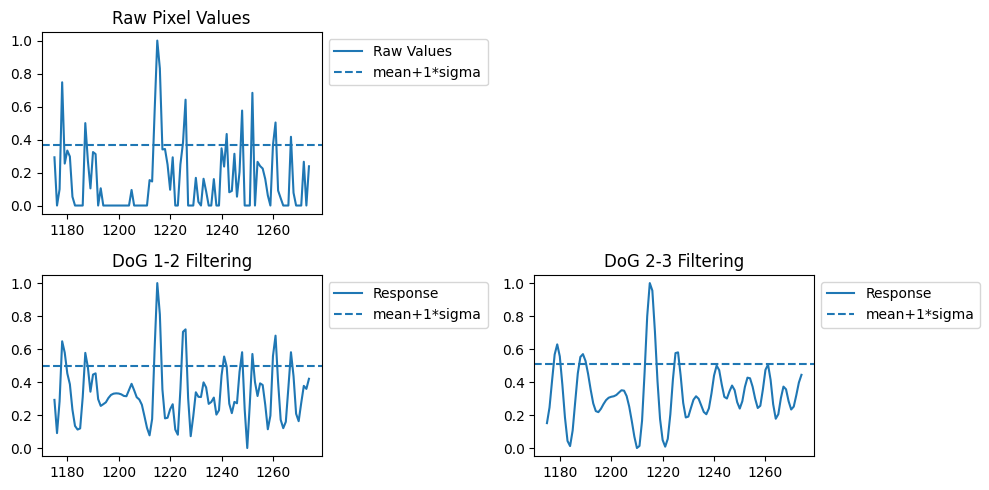

In [7]:
# Select a star for 1-D profile study
expected_locn = (1214, 1225)

win_len = 50
buff_len = 5
x_vals = range(expected_locn[1]-win_len, expected_locn[1]+win_len, 1)
pixel_row = img2[expected_locn[0], x_vals]

dog12_row_result = aplm.dog_1d(pixel_row, sigma_hi=1, sigma_lo=2)
dog23_row_result = aplm.dog_1d(pixel_row, sigma_hi=2, sigma_lo=3)

dog12_norm_bg_vals = aplm.background_sample_1d(aplm.norm_array(dog12_row_result), exp_locn=(expected_locn[1]-x_vals[0]), buffer_len=5)
dog23_norm_bg_vals = aplm.background_sample_1d(aplm.norm_array(dog23_row_result), exp_locn=(expected_locn[1]-x_vals[0]), buffer_len=5)

plt.rcParams['figure.figsize'] = [10, 5]
plt.figure()
plt.subplot(2,2,1)
raw_plot, = plt.plot(x_vals, aplm.norm_array(pixel_row), label='Raw Values')
norm_bg_vals = aplm.background_sample_1d(aplm.norm_array(pixel_row), exp_locn=(expected_locn[1]-x_vals[0]), buffer_len=5)
plt.axhline(norm_bg_vals[0]+norm_bg_vals[1], linestyle='--', color=raw_plot.get_color(), label='mean+1*sigma')
plt.title('Raw Pixel Values')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.subplot(2,2,3)
pdog12, = plt.plot(x_vals, aplm.norm_array(dog12_row_result), label='Response')
plt.axhline(dog12_norm_bg_vals[0]+dog12_norm_bg_vals[1], linestyle='--', color=pdog12.get_color(), label='mean+1*sigma')
plt.title('DoG 1-2 Filtering')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.subplot(2,2,4)
pdog23, = plt.plot(x_vals, aplm.norm_array(dog23_row_result), label='Response')
plt.axhline(dog23_norm_bg_vals[0]+dog23_norm_bg_vals[1], linestyle='--', color=pdog23.get_color(), label='mean+1*sigma')
plt.title('DoG 2-3 Filtering')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

In [8]:
# Crop star and optimize DoG level
img2_crop = clean_img2[1164:1264,1175:1275]
max_row, max_col = np.unravel_index(np.argmax(img2_crop.flatten()), img2_crop.shape)

best_lvl = -1
best_snr = 0
min_max_amplitudes = []

for i in range(2):
    for lvl in range(4):
        crop_dog_lvl = aplm.dog_2d(img2_crop, sigma_hi=lvl, sigma_lo=(lvl+1), mode='reflect')
        if i == 0:
            min_max_amplitudes.append([np.min(crop_dog_lvl), np.max(crop_dog_lvl)])
            continue
            
        crop_dog_lvl_norm = aplm.norm_array(crop_dog_lvl)
        bg_stats_lvl = aplm.background_sample_2d(crop_dog_lvl_norm, (max_row, max_col), (5,5))
        lvl_snr = (1-bg_stats_lvl[0])/bg_stats_lvl[1]
        if lvl_snr > best_snr:
            best_snr = lvl_snr
            best_lvl = lvl

print(f"Best DoG Level: {best_lvl}-{best_lvl+1} with SNR: {best_snr:.2f}")

Best DoG Level: 0-1 with SNR: 7.72


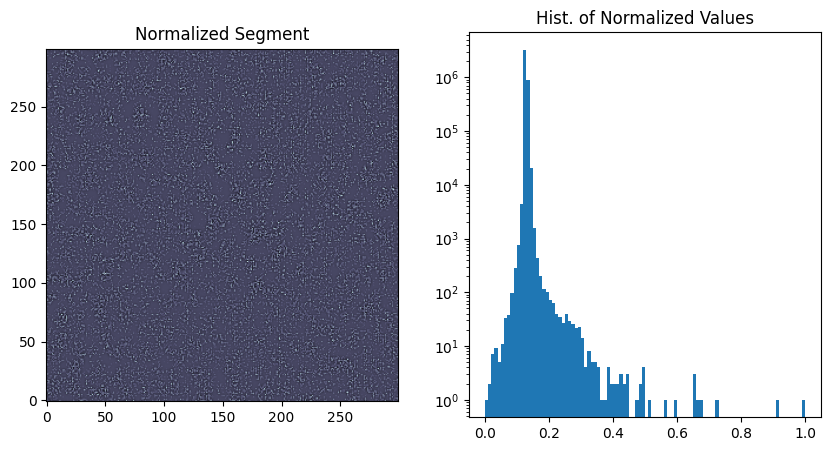

In [9]:
# Apply best DoG to full image
best_dog_lvl = aplm.norm_array(
                aplm.dog_2d(clean_img2,
                            sigma_hi=best_lvl,
                            sigma_lo=(best_lvl+1),
                            mode='reflect'
                            )
                )

plt.subplot(1,2,1)
plt.imshow(best_dog_lvl[1064:1364,1075:1375], cmap='bone', origin='lower')
plt.title('Normalized Segment')

plt.subplot(1,2,2)
myHist100(best_dog_lvl)
plt.yscale('log')
plt.title('Hist. of Normalized Values')
plt.show()

## When Does Measurement Happen?

Previously in this post I mention that all of the filtering is a <u>localization</u> tool, but the filtered result is not what should be <u>measured</u>. Following the general process defined by O'Haver, I use the best SNR DoG result to locate the strongest filter responses and then use that as an initial guess for where to measure the (unfiltered) pixel values from the `best_stacked_image.fits`. Assuming that the calibration and stacking pipeline produced calibrated pixel values, the measurement hereafter would be generating peak flux and total integrated flux observed by the instrument.

The first [unofficial] step I take is making sure that the point I'm about to study is spatially unique from previously analyzed points. I did not analytically calculate the point spread function before starting this section, so determining the spatial tolerance for "unique" points was done iteratively. The same is true for determining the "extent" of pixels to crop out. 

The second step is using the background pixel values near the star/object to set a threshold. Values significantly above that threshold will be used to find the centroid of the star. If the thresholding weren't accomplished, the centroid would be biased by the raw shape of the cropped section. The threshold-and-centroid process produces a subpixel coordinate for the center of the star/object. 

The final step is calculating the distance from every measured pixel value to the centroid location then plotting the pixel values vs the pixel distance. If the point of interest is indeed an external, bright object (as opposed to a hot pixel) the resulting plot will look like half of a Gaussian curve. This is a direct representation of the point spread function. I learned this approach while watching [Richard Berry's "How to Understand Star Photometry"](https://www.youtube.com/watch?v=ufbFaUywEBg&t=6878s) on the American Association of Variable Star Observers (AAVSO) YouTube page.

Star at original (7, 1747) adjusted to (7, 1747)
Centroid relative coordinates: (7, 8)
Integrated Counts: 0.94



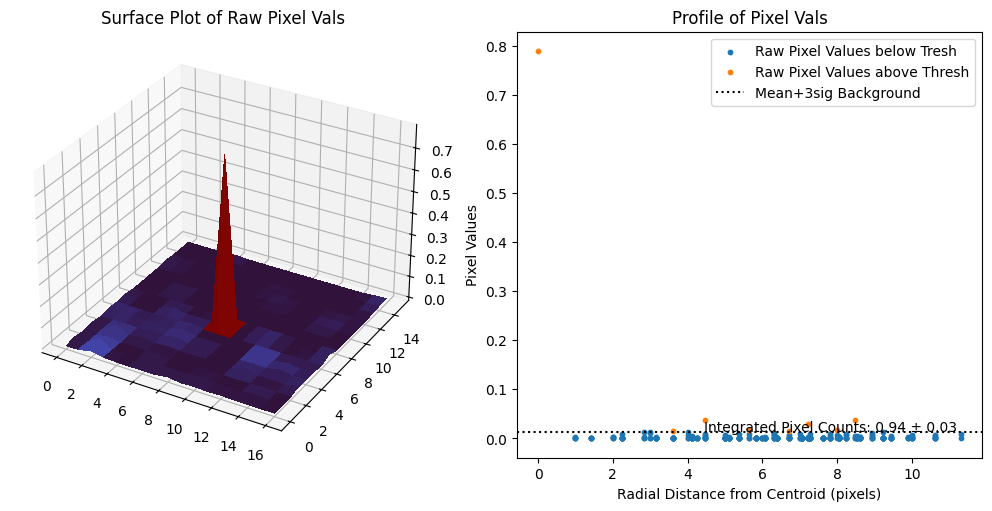

Star at original (3, 1481) adjusted to (3, 1481)
Centroid relative coordinates: (3, 8)
Integrated Counts: 1.15



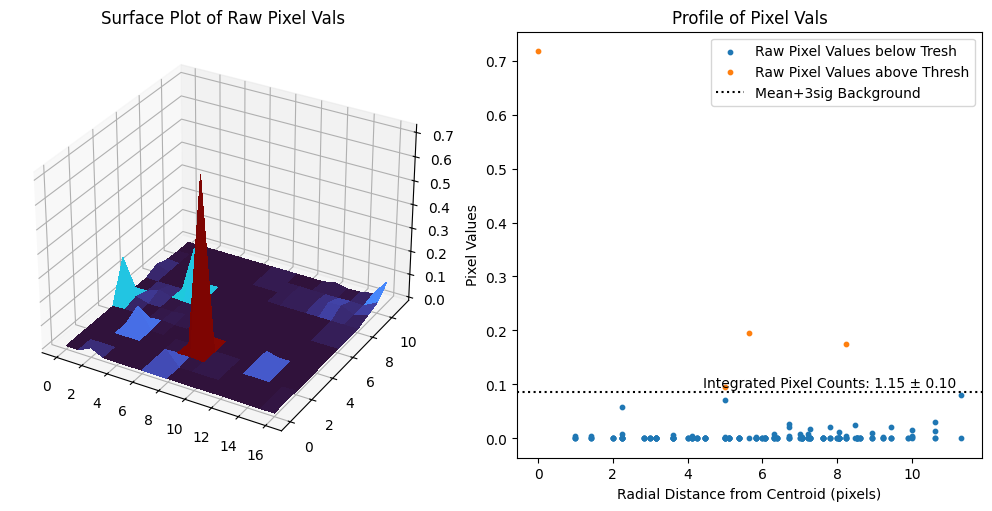

Star at original (7, 1582) adjusted to (7, 1582)
Centroid relative coordinates: (7, 8)
Integrated Counts: 1.19



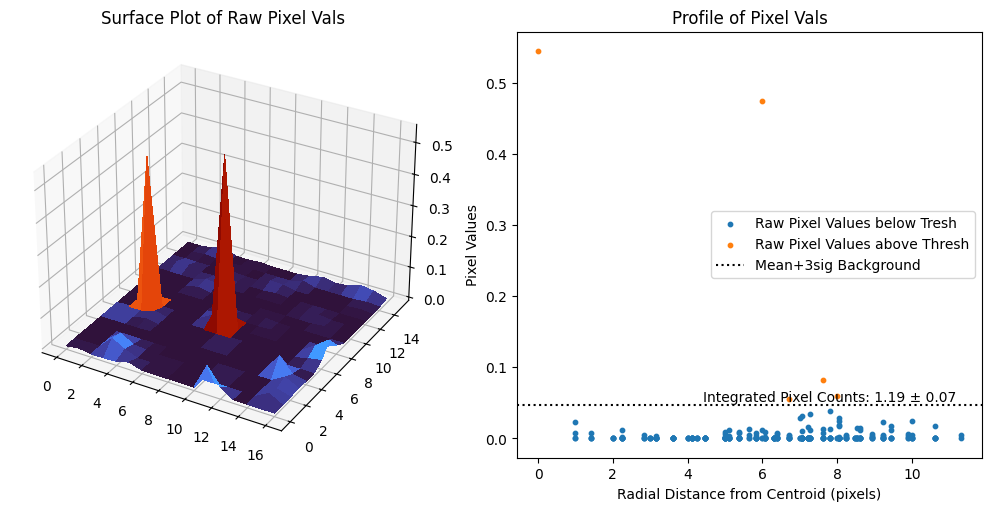

Star at original (0, 1697) adjusted to (0, 1697)
Centroid relative coordinates: (0, 8)
Integrated Counts: 1.47



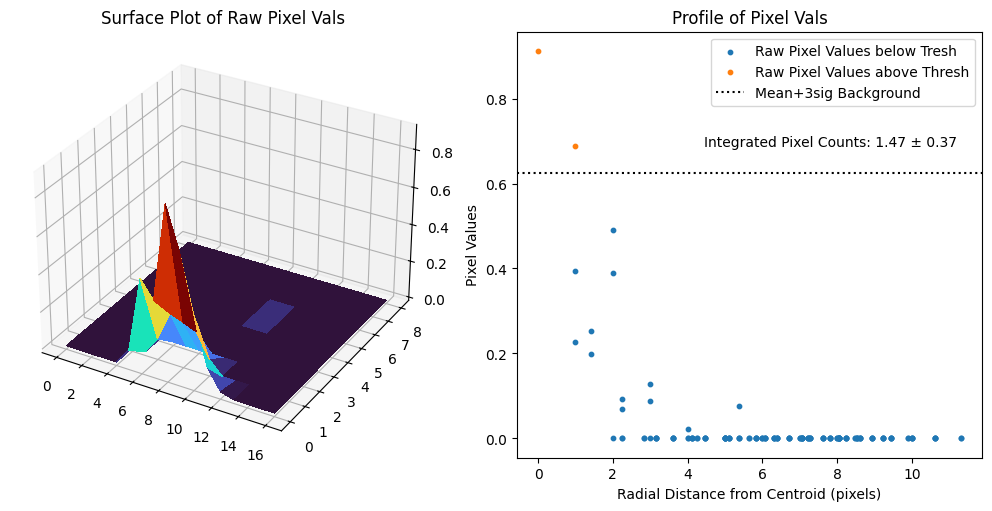

Star at original (19, 1339) adjusted to (19, 1339)
Centroid relative coordinates: (8, 8)
Integrated Counts: 0.82



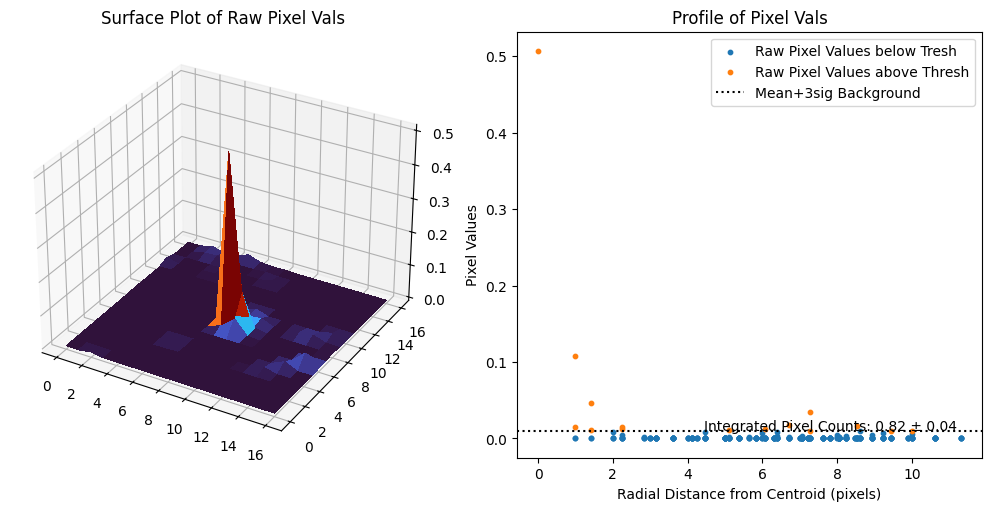

Star at original (3, 1439) adjusted to (3, 1439)
Centroid relative coordinates: (3, 8)
Integrated Counts: 0.84



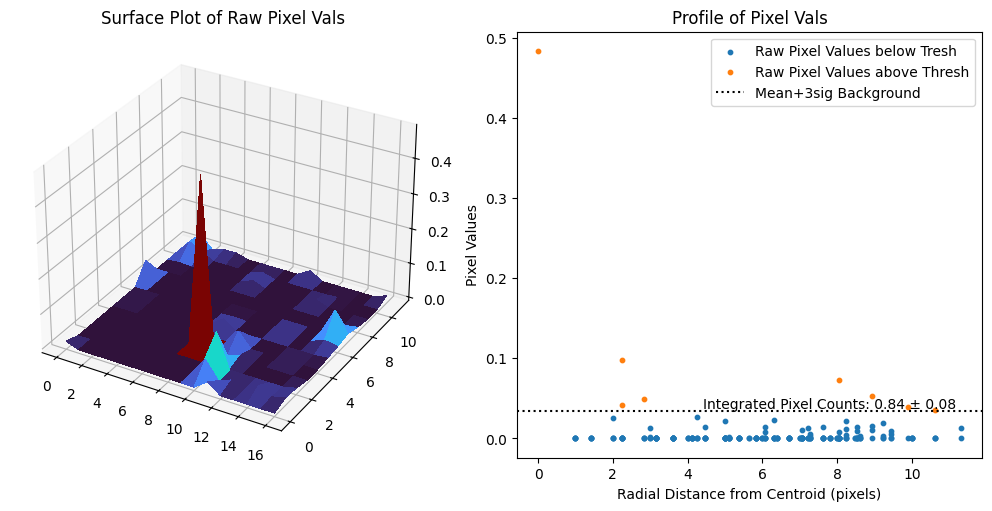

Star at original (7, 1377) adjusted to (7, 1377)
Centroid relative coordinates: (7, 8)
Integrated Counts: 1.21



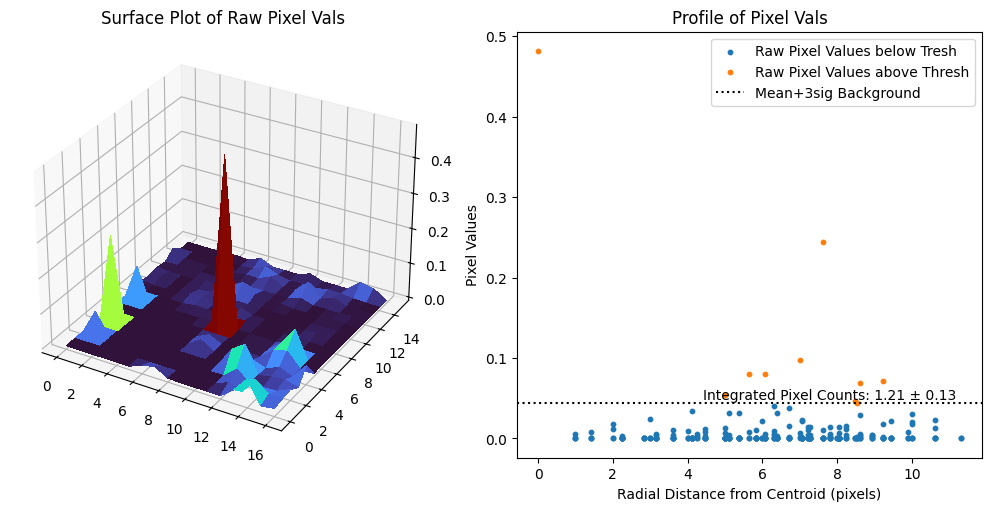

Star at original (0, 1624) adjusted to (0, 1624)
Centroid relative coordinates: (0, 8)
Integrated Counts: 0.47



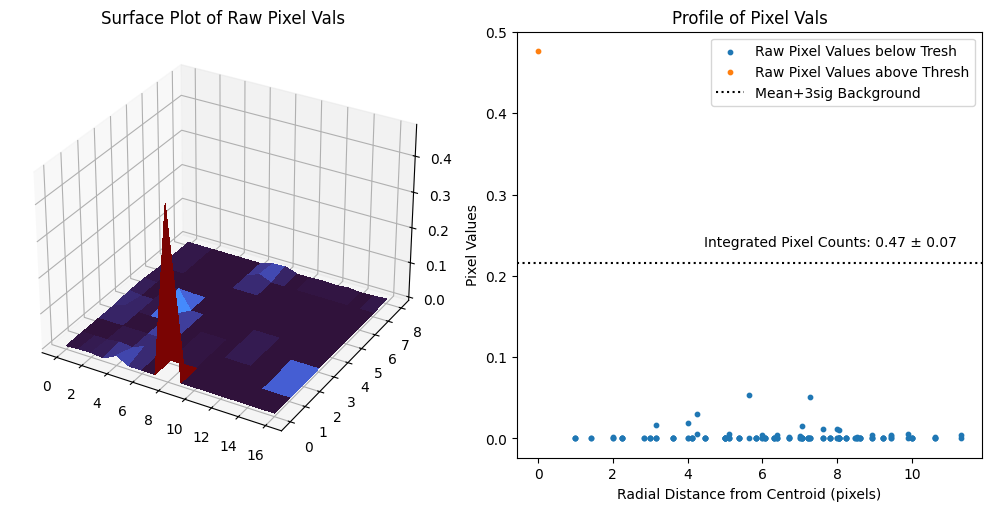

Star at original (5, 1553) adjusted to (5, 1553)
Centroid relative coordinates: (5, 8)
Integrated Counts: 1.26



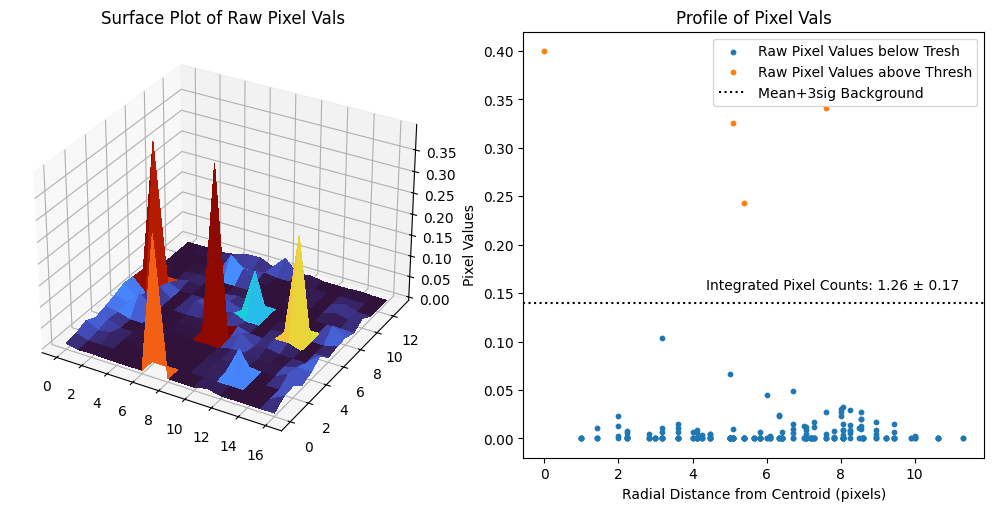

Star at original (0, 1490) adjusted to (0, 1490)
Centroid relative coordinates: (0, 8)
Integrated Counts: 0.89



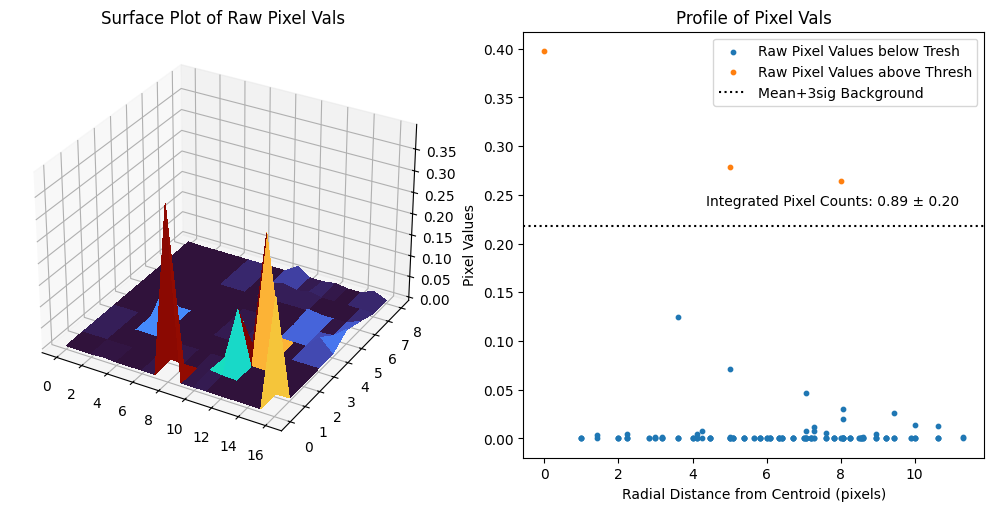

In [10]:
# Find unique coordinates and run sub-pixel centroid analysis
extent = [8,8]
sorted_dog_coords = np.unravel_index(np.argsort(best_dog_lvl.flatten())[::-1], best_dog_lvl.shape)
unique_maxs = aplm.get_unique_points(coords = sorted_dog_coords, num_required = 10, extent = extent*2)

for rmax_dog, cmax_dog in unique_maxs:
    local_pixels_raw = aplm.get_adjacent_pixels(img2, (rmax_dog, cmax_dog), extent=extent, remove_mid=False)  
    rmax_new, cmax_new = aplm.adjust_guess_location(img2, rmax_dog, cmax_dog, extent)
    if (rmax_new!=rmax_dog) | (cmax_new!=cmax_dog):
        local_pixels_raw = aplm.get_adjacent_pixels(img2, (rmax_new, cmax_new), extent=extent, remove_mid=False) 
        
    border_stats = aplm.get_border_stats(local_pixels_raw)
    thresh = border_stats[0]+3*border_stats[1]
    
    mask = np.ma.masked_where(local_pixels_raw>=thresh, local_pixels_raw)
    mask.data[mask.mask==False] = 0
    local_max_locn = np.unravel_index(np.argmax(mask.data), mask.shape)
    
    # Corrected grid and distance calculations to avoid shape mismatch on non-square crops
    X, Y = np.meshgrid(np.arange(local_pixels_raw.shape[1]), np.arange(local_pixels_raw.shape[0]))
    pix_distances = np.sqrt(np.square(Y - local_max_locn[0]) + np.square(X - local_max_locn[1]))
    
    integrated_counts = np.sum(local_pixels_raw[mask.mask==True]-border_stats[0])
    
    print(f"Star at original ({rmax_dog}, {cmax_dog}) adjusted to ({rmax_new}, {cmax_new})")
    print(f"Centroid relative coordinates: ({local_max_locn[0]}, {local_max_locn[1]})")
    print(f"Integrated Counts: {integrated_counts:.2f}\n")

    plt.figure(layout='constrained')
    ax = plt.subplot(1,2,1,projection='3d')
    ax.plot_surface(X, Y, local_pixels_raw, cmap='turbo', linewidth=0, antialiased=False)
    plt.title('Surface Plot of Raw Pixel Vals')
    
    plt.subplot(1,2,2)
    plt.scatter(np.abs(np.ravel(pix_distances[mask.mask==False])),
                np.ravel(local_pixels_raw[mask.mask==False]),
                s=10,
                label='Raw Pixel Values below Tresh')
    plt.scatter(np.abs(np.ravel(pix_distances[mask.mask==True])),
                np.ravel(local_pixels_raw[mask.mask==True]),
                s=10,
                label='Raw Pixel Values above Thresh')
    plt.axhline(thresh,
                linestyle=':',
                color='black',
                label='Mean+3sig Background')
    plt.title('Profile of Pixel Vals')
    plt.xlabel('Radial Distance from Centroid (pixels)')
    plt.ylabel('Pixel Values')
    plt.text(np.max(pix_distances),1.1*thresh, 
        'Integrated Pixel Counts: {:.2f} \u00B1 {:.2f} '. 
        format(integrated_counts, np.count_nonzero(mask)*border_stats[1]),
        ha='right',
        )
    
    plt.legend()
    plt.show()
